# PPO Training Example on ImprovedLAPANEnv

This notebook demonstrates training a PPO agent from `tensoraerospace/agent/ppo/model.py` on the `ImprovedLAPANEnv` environment from `tensoraerospace/envs/lapan.py`.

**Environment features:**
- LAPAN satellite control
- Parameter tracking during stabilization
- Normalized action and observation spaces [-1, 1]
- LQR-like reward function

**Algorithm features:**
- Continuous actions with Gaussian policy
- Clipped surrogate objective for stable updates
- tqdm progress bar and TensorBoard logging
- Checkpointing for resuming training

In [1]:
# Optional installs (run if needed)
# %pip install tensorboard tqdm --quiet

import os
import numpy as np
import torch

from tensoraerospace.envs import ImprovedLAPANEnv
from tensoraerospace.agent.ppo.model import PPO

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", DEVICE)

# Reproducibility
np.random.seed(42)
_ = torch.manual_seed(42)


Using device: mps


In [2]:
# Build environment
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# Time base
from tensoraerospace.signals.standart import sinusoid_vertical_shift
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# Time base
dt = 0.1
_tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(_tp, dt=dt)
number_time_steps = len(_tp)

# Reference theta (radians)
reference_signals = np.reshape(
    sinusoid_vertical_shift(
        tp=np.asarray(tps),
        frequency=0.05,
        amplitude=np.deg2rad(1.0),
        vertical_shift=0.0,
    ),
    [1, -1],
)

# Initial state [rho (km), rho_dot (m/s), theta_dot (rad/s)]
# Start at Earth radius with target angular velocity
init_state = np.array([0.0,0.0, 0.0, 0.0], dtype=np.float32)

# Env
env = ImprovedLAPANEnv(
    initial_state=init_state,
    reference_signal=reference_signals,
    number_time_steps=number_time_steps,
    dt=dt,
    initial_elevator_deg= 0.0
)

obs, info = env.reset()
print("Obs shape:", np.array(obs).shape)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print("\nEnvironment configuration:")
print(f"  dt: {env.dt} sec")
print(f"  Steps: {number_time_steps}")
print(f"  Duration: {number_time_steps * env.dt:.1f} sec")
print(f"  Reward scale: {env.reward_scale}")
print(f"  Survival bonus: +0.1 per step")


Obs shape: (4,)
Action space: Box(-1.0, 1.0, (1,), float32)
Observation space: Box(-1.0, 1.0, (4,), float32)

Environment configuration:
  dt: 0.1 sec
  Steps: 201
  Duration: 20.1 sec
  Reward scale: 0.1
  Survival bonus: +0.1 per step


In [3]:
# Create PPO agent (tuned hyperparams)
# Hyperparameters for ComSat:
# - Higher gamma (0.99) for long-term orbital stability
# - Larger rollout_len (2048) for diverse trajectory collection
# - Moderate clip_param (0.2) balances exploration and stability
# - Lower entropy_coef (0.01) reduces randomness for precise control
# - Smaller learning rates for satellite control
# - normalize_obs=True for stable learning with normalized observations

agent = PPO(
    env=env,
    gamma=0.99,                # discount factor
    max_episodes=1000,         # total training episodes
    rollout_len=2048,          # steps per rollout
    clip_pram=0.2,             # PPO clip parameter
    num_epochs=10,             # optimization epochs per rollout
    batch_size=64,             # minibatch size
    entropy_coef=0.01,         # entropy bonus coefficient
    actor_lr=3e-4,             # policy learning rate
    critic_lr=1e-3,            # value function learning rate
    gae_lambda=0.95,           # GAE lambda
    max_grad_norm=0.5,         # gradient clipping
    target_kl=0.015,           # early stopping KL threshold
    normalize_obs=True,        # normalize observations
    normalize_reward=False,    # don't normalize rewards (already scaled)
    seed=42,
)

print("PPO agent created")
# print(f"Actor network: {agent.policy_network}")
# print(f"\nValue network: {agent.value_network}")


PPO agent created


## Training

**Training recommendations:**

1. **Start simple** - use a constant target angular velocity
2. **Monitor metrics:**
   - `mean_reward` - should increase and stabilize
   - `entropy` - should decrease as the policy converges
   - `policy_loss` and `value_loss` - should decrease
   - `approx_kl` - should remain small (~0.01)

3. **Signs of successful training:**
   - Reward > -10 (agent avoids termination)
   - Mean reward grows to ~-5 or higher
   - Agent completes all 200 steps without termination

4. **If training stalls:**
   - Check metrics in TensorBoard: `tensorboard --logdir runs/`
   - Halve `actor_lr` and `critic_lr`
   - Increase `rollout_len` to 4096
   - Try `normalize_reward=True`

In [4]:
# Train the agent
# This will take some time depending on your hardware
# Progress will be shown via tqdm progress bar
# Metrics are logged to TensorBoard in runs/ directory

print("Starting training...")
print(f"Total episodes: {agent.max_episodes}")
print(f"Rollout length: {agent.rollout_len}")
print(f"Expected total steps: ~{agent.max_episodes * agent.rollout_len // number_time_steps}")
print("\nMonitor training: tensorboard --logdir runs/\n")

# Train
agent.train()

print("\nTraining completed!")


Starting training...
Total episodes: 1000
Rollout length: 2048
Expected total steps: ~10189

Monitor training: tensorboard --logdir runs/



  0%|          | 0/1000 [00:00<?, ?it/s]

  1%|          | 10/1000 [00:09<15:03,  1.10it/s]


New best model! Reward: -106.11 (episode 10)


  2%|▏         | 20/1000 [00:17<12:55,  1.26it/s]

...


New best model! Reward: -0.00 (episode 880)


 98%|█████████▊| 980/1000 [12:49<00:15,  1.30it/s]


New best model! Reward: -0.00 (episode 980)


100%|██████████| 1000/1000 [13:04<00:00,  1.27it/s]


Training completed!


In [22]:
# Evaluation run
obs, info = env.reset()
done = False
ret = 0.0
step = 0

while not done and step < number_time_steps:
    action = agent.act(obs, deterministic=False)
    step_return = env.step(action)
    if len(step_return) == 5:
        obs, reward, terminated, truncated, info = step_return
        done = terminated or truncated
    else:
        obs, reward, terminated, info = step_return[:4]
        done = terminated
    ret += float(reward)
    step += 1

print(f"Evaluation reward: {ret:.3f}")
step

Evaluation reward: -0.002


199

In [6]:
# Save the trained model
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

agent.save(checkpoint_dir)
print(f"Model saved to {checkpoint_dir}")

# To load later:
# agent = PPO.load(checkpoint_dir)

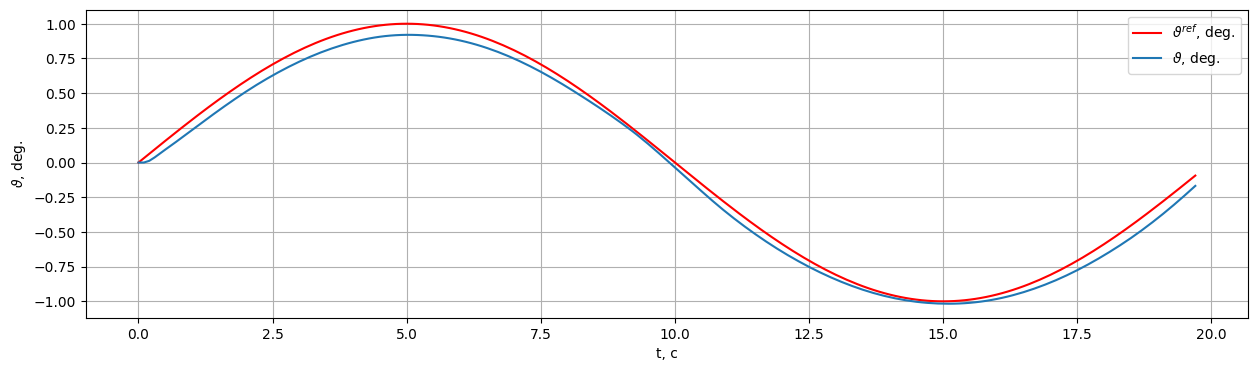

In [8]:
# Plot theta (pitch angle) tracking
env.unwrapped.model.plot_transient_process('theta', tps, reference_signals[0], to_deg=True, figsize=(15,4))

/Users/asmazaev/TensorAeroSpace-Origin/tensoraerospace/aerospacemodel/base.py:383: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


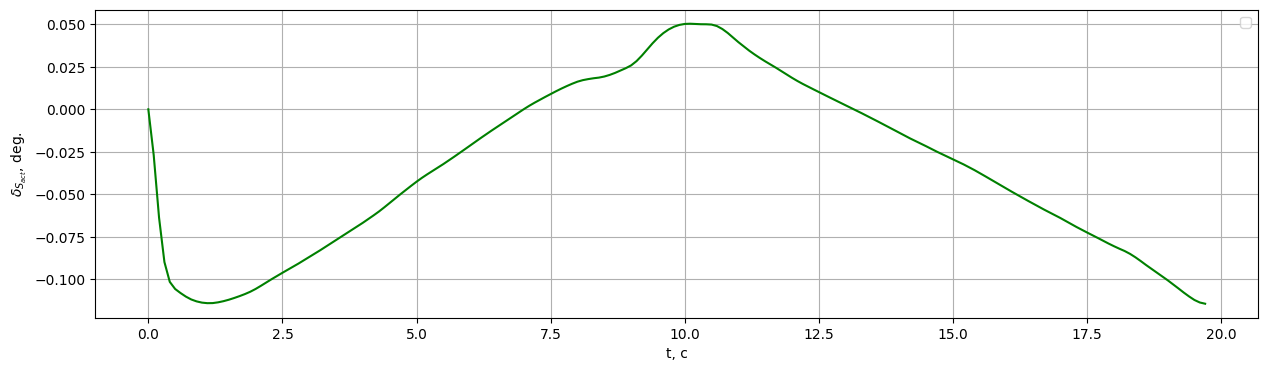

In [7]:
# Plot elevator control
env.unwrapped.model.plot_control(control_name='ele', time=tps, to_deg=True, figsize=(15,4))


## Evaluation of the Trained Model

Test the trained agent on a single episode and collect data for visualization.